In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # A library for making pretty charts

# Load the CLEAN data we just saved
# We rely on the processed folder now, not raw.
news_df = pd.read_csv("../data/processed/news_data_cleaned.csv")
stock_df = pd.read_csv("../data/processed/stock_prices_combined.csv")

# Ensure dates are read correctly (CSVs sometimes lose this info)
news_df["date"] = pd.to_datetime(news_df["date"])
stock_df["date"] = pd.to_datetime(stock_df["date"])

print("Data Loaded for Analysis!")


Data Loaded for Analysis!


In [6]:
# 1. Create a new column for length
news_df["headline_len"] = news_df["headline"].str.len()

In [7]:
# 2. Basic Statistics
# This gives Mean, Min, Max, and quartiles for the length
print("--- Headline Length Statistics ---")
print(news_df["headline_len"].describe())

--- Headline Length Statistics ---
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64


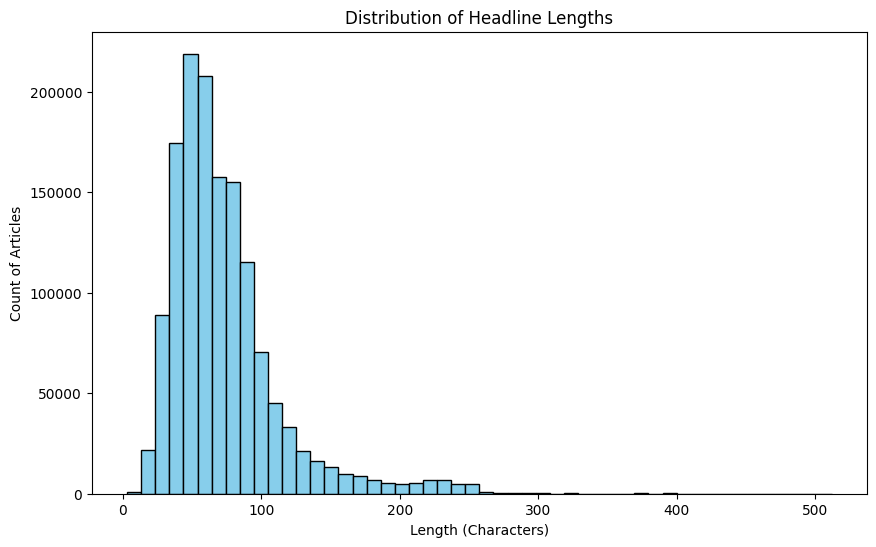

In [19]:
# 3.Visualization (Histogram) pf the headline length
plt.figure(figsize=(10, 6))  # Set chart size (10 inches wide, 6 tall)
plt.hist(news_df["headline_len"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribution of Headline Lengths")
plt.xlabel("Length (Characters)")
plt.ylabel("Count of Articles")
plt.show()


In [22]:
# 1. Count the Publishers
# .value_counts() counts how many times each name appears
# .head(10) keeps only the top 10 results
publisher_counts = news_df["publisher"].value_counts().head(10)

print("--- Top 10 Publishers ---")
print(publisher_counts)

--- Top 10 Publishers ---
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


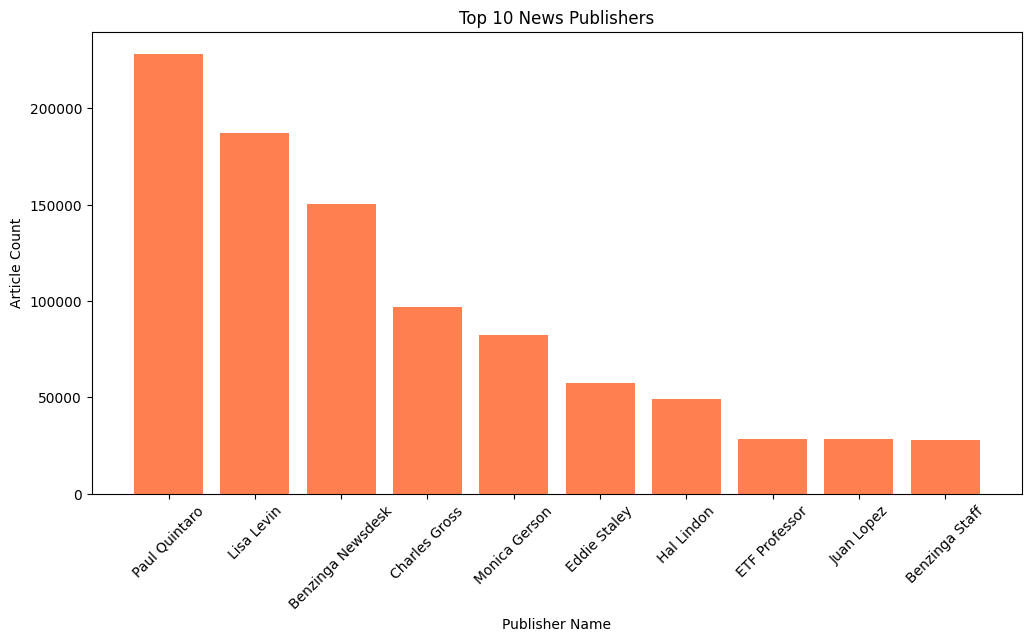

In [ ]:
# 2. Visualize it (Bar Chart)
plt.figure(figsize=(12, 6))

plt.bar(publisher_counts.index, publisher_counts.values, color="coral")

plt.title("Top 10 News Publishers")
plt.xlabel("Publisher Name")
plt.ylabel("Article Count")
plt.xticks(rotation=45)  # Rotate the names 45 degrees so they don't overlap!
plt.show()


the next step is Visualizing Publication Frequency
We will count how many articles were published per day.
steps:
# 1. Set the Date as the Index
# Pandas needs the Date to be the "Index"
# to allow us to slice and dice by time.
# We create a temporary DataFrame 'daily_news' so we don't mess up the original
# 2. Resample by Day ('D') and Count
# This says: "Group everything by Day (D) and count the rows (.size())"
# If you wanted Monthly, you would use 'M'.
# 3. Plotting the Time Series

In [23]:
#1
daily_news = news_df.set_index("date")

In [30]:
#2
daily_counts = daily_news.resample("D").size()
print("--- Daily Article Counts ---")
print(daily_counts.head())
print("----the recent articles-------")
print(daily_counts.tail())

--- Daily Article Counts ---
date
2011-04-28 00:00:00+00:00    3
2011-04-29 00:00:00+00:00    2
2011-04-30 00:00:00+00:00    1
2011-05-01 00:00:00+00:00    1
2011-05-02 00:00:00+00:00    9
dtype: int64
----the recent articles-------
date
2020-06-07 00:00:00+00:00     25
2020-06-08 00:00:00+00:00    765
2020-06-09 00:00:00+00:00    803
2020-06-10 00:00:00+00:00    807
2020-06-11 00:00:00+00:00    544
dtype: int64


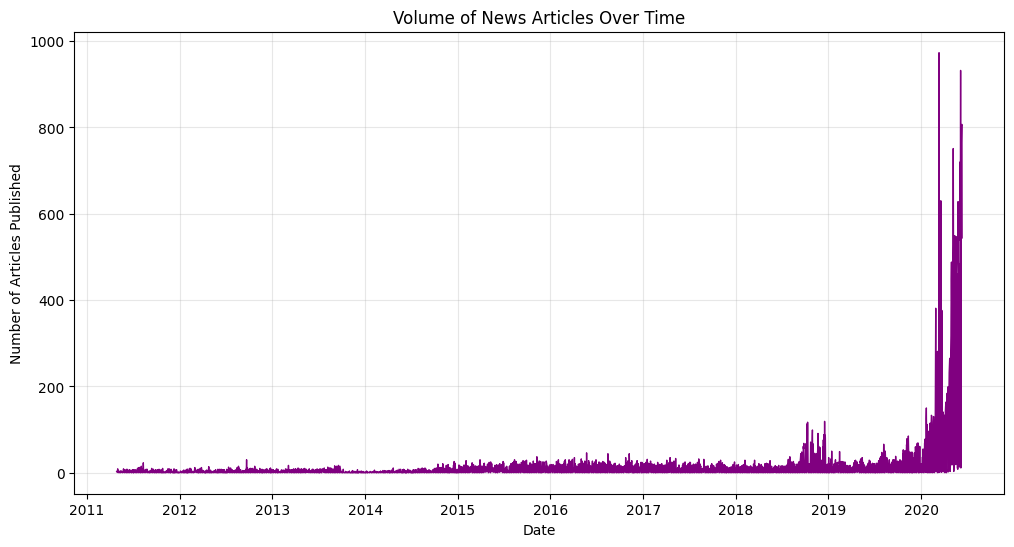

In [27]:
# 3. Plotting the Time Series
plt.figure(figsize=(12, 6))
plt.plot(daily_counts.index, daily_counts.values, color="purple", linewidth=1)

plt.title("Volume of News Articles Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles Published")
plt.grid(True, alpha=0.3)  # Adds a light grid to make it easier to read
plt.show()


Keyword Frequencies and  Topic Modeling

In [31]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# 1. Take a sample to speed up calculation
# We take the most recent 20,000 headlines (tail)
subset_news = news_df.tail(20000)
headlines = subset_news["headline"].dropna()

# 2. Initialize the Counter (The "Robot")
# ngram_range=(2, 2) means "look for pairs of 2 words" (Bigrams)
# stop_words='english' means "ignore words like 'the', 'an', 'in'"
vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words="english")

# 3. Fit and Transform (The Math)
# This converts text into a giant matrix of numbers
bow_matrix = vectorizer.fit_transform(headlines)

# 4. Sum up the counts
# sum(axis=0) adds up the columns (totals per word-pair)
total_counts = bow_matrix.sum(axis=0)

# 5. Convert to a readable list
# We grab the words (feature_names) and their counts
words = vectorizer.get_feature_names_out()
counts = np.asarray(total_counts)[0]

# Create a DataFrame to sort them
keyword_df = pd.DataFrame({"keyword": words, "count": counts})
keyword_df = keyword_df.sort_values(by="count", ascending=False)

print("--- Top 10 Key Phrases in Recent News ---")
print(keyword_df.head(10))


--- Top 10 Key Phrases in Recent News ---
                  keyword  count
45225        option alert    659
71198          yum brands    605
60717       stocks moving    596
48418        price target    541
47960          pre market    470
40347       market update    465
7067              52 week    458
35170  initiates coverage    429
41335             mid day    428
25240  earnings scheduled    377
